In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

release_name = "analysis_release_v1_20261005T194400349609Z"

current_dir = Path.cwd().resolve()
ROOT = next(
    (
        folder
        for folder in [current_dir, *current_dir.parents]
        if (folder / "data" / "processed" / release_name).is_dir()
    ),
    None
)

if ROOT is None:
    raise FileNotFoundError("Không tìm thấy thư mục dữ liệu release.")

RELEASE_DIR = ROOT / "data" / "processed" / release_name

panel = pd.read_csv(
    RELEASE_DIR / "game_monthly_panel.csv",
    encoding="utf-8-sig"
)

panel["month_start"] = pd.to_datetime(
    panel["month_start"], errors="raise"
)

for column in ["source_prize_pool_usd", "hours_watched"]:
    panel[column] = pd.to_numeric(
        panel[column], errors="raise"
    )

assert panel[["game_family", "month_start"]].notna().all().all()
assert not panel.duplicated(["game_family", "month_start"]).any()

# Cùng khoảng thời gian với phần EDA Twitch
relation_data = panel.loc[
    panel["month_start"].between("2020-04-01", "2024-09-01")
].copy()

# Chỉ dùng những tháng có cả hai chỉ tiêu, không điền thiếu bằng 0
relation_data["valid_pair"] = (
    relation_data[["source_prize_pool_usd", "hours_watched"]]
    .notna().all(axis=1)
)

pair_summary = (
    relation_data.groupby("game_family")
    .agg(
        so_thang=("month_start", "size"),
        so_thang_du_cap=("valid_pair", "sum"),
    )
)

pair_summary["so_thang_thieu_cap"] = (
    pair_summary["so_thang"] - pair_summary["so_thang_du_cap"]
)

display(pair_summary)

paired = relation_data.loc[
    relation_data["valid_pair"]
].copy()

assert paired["source_prize_pool_usd"].ge(0).all()
assert paired["hours_watched"].ge(0).all()

,so_thang,so_thang_du_cap,so_thang_thieu_cap
game_family,,,
Counter-Strike,54,54,0
Dota 2,54,54,0
League of Legends,54,54,0
Valorant,54,53,1


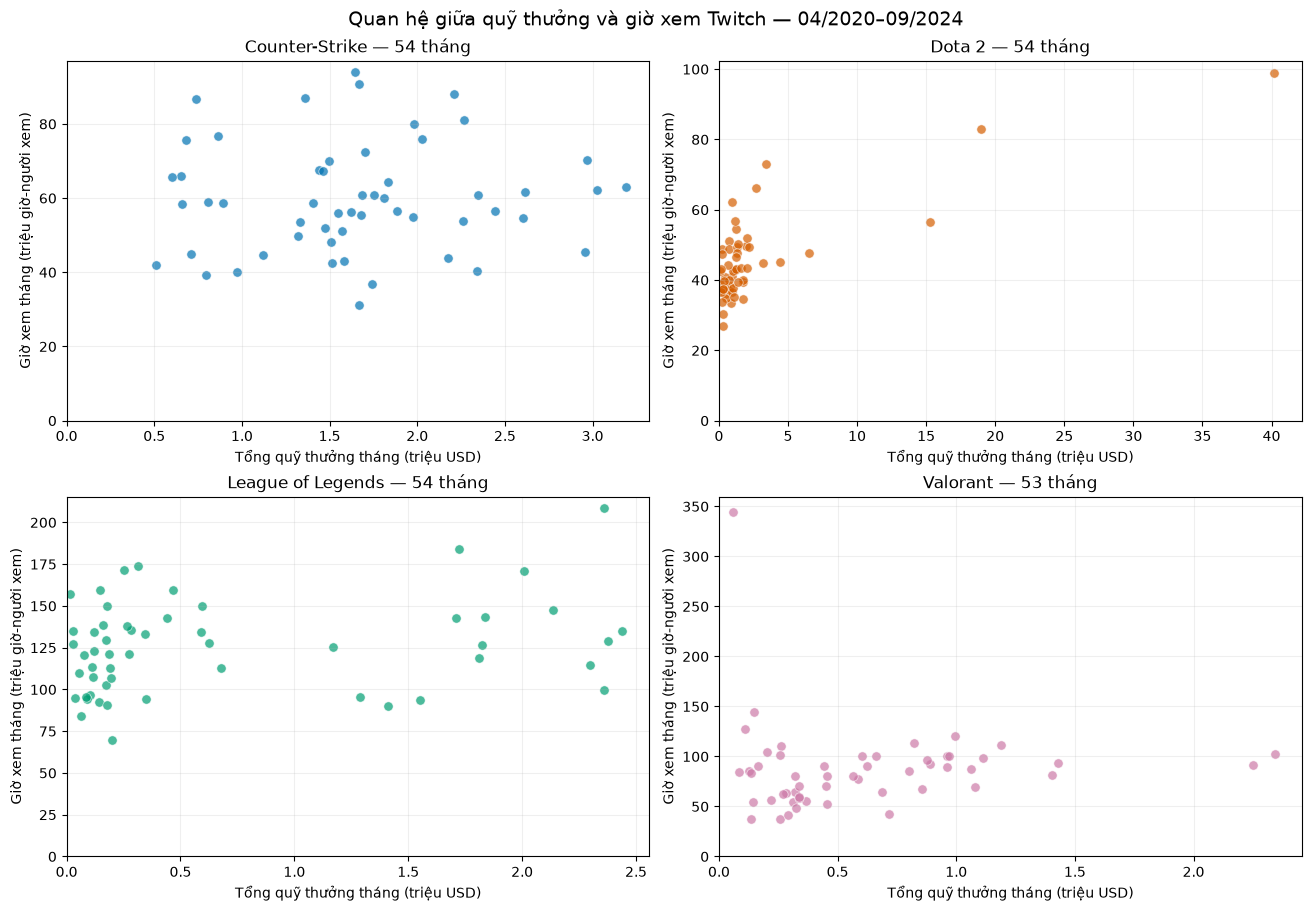

In [2]:
games = [
    "Counter-Strike",
    "Dota 2",
    "League of Legends",
    "Valorant",
]

colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]

fig, axes = plt.subplots(
    2, 2,
    figsize=(13, 9),
    layout="constrained"
)

for ax, game, color in zip(axes.flat, games, colors):
    game_data = paired.loc[
        paired["game_family"].eq(game)
    ]

    ax.scatter(
        game_data["source_prize_pool_usd"] / 1_000_000,
        game_data["hours_watched"] / 1_000_000,
        color=color,
        alpha=0.7,
        s=45,
        edgecolors="white",
        linewidths=0.5,
    )

    ax.set_title(f"{game} — {len(game_data)} tháng")
    ax.set_xlabel("Tổng quỹ thưởng tháng (triệu USD)")
    ax.set_ylabel("Giờ xem tháng (triệu giờ-người xem)")
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.2)

fig.suptitle(
    "Quan hệ giữa quỹ thưởng và giờ xem Twitch — 04/2020–09/2024",
    fontsize=14
)

plt.show()

In [3]:
rows = []

for game in games:
    data = paired.loc[
        paired["game_family"].eq(game),
        ["source_prize_pool_usd", "hours_watched"]
    ].dropna()

    x = data["source_prize_pool_usd"]
    y = data["hours_watched"]

    # Pearson: mức độ liên hệ tuyến tính trên giá trị gốc
    pearson = x.corr(y, method="pearson")

    # Spearman: tương quan giữa thứ hạng
    # Các giá trị bằng nhau được gán thứ hạng trung bình
    spearman = (
        x.rank(method="average")
        .corr(y.rank(method="average"), method="pearson")
    )

    rows.append({
        "Game": game,
        "Số tháng": len(data),
        "Pearson": pearson,
        "Spearman": spearman,
    })

correlation_table = pd.DataFrame(rows).set_index("Game")

display(correlation_table.round(3))

,Số tháng,Pearson,Spearman
Game,,,
Counter-Strike,54,0.043,0.084
Dota 2,54,0.760,0.565
League of Legends,54,0.256,0.267
Valorant,53,0.024,0.218


In [4]:
sensitivity_rows = []

for game in games:
    data = paired.loc[
        paired["game_family"].eq(game),
        ["month_start", "source_prize_pool_usd", "hours_watched"]
    ].copy()

    metrics = ["source_prize_pool_usd", "hours_watched"]

    q1 = data[metrics].quantile(0.25)
    q3 = data[metrics].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # Đánh dấu nếu ít nhất một chỉ tiêu nằm ngoài ngưỡng
    outside_iqr = (
        data[metrics].lt(lower)
        | data[metrics].gt(upper)
    ).any(axis=1)

    for label, sample in [
        ("Toàn bộ", data),
        ("Không xét tháng ngoài ngưỡng IQR", data.loc[~outside_iqr]),
    ]:
        x = sample["source_prize_pool_usd"]
        y = sample["hours_watched"]

        # Không tính tương quan nếu quá ít mẫu hoặc chỉ tiêu không biến động
        can_compute = (
            len(sample) >= 3
            and x.nunique() > 1
            and y.nunique() > 1
        )

        sensitivity_rows.append({
            "Game": game,
            "Tập so sánh": label,
            "Số tháng": len(sample),
            "Pearson": x.corr(y) if can_compute else float("nan"),
            "Spearman": (
                x.rank().corr(y.rank())
                if can_compute else float("nan")
            ),
        })

sensitivity_table = pd.DataFrame(sensitivity_rows)

display(
    sensitivity_table
    .set_index(["Game", "Tập so sánh"])
    .round(3)
)

Số tháng  Pearson  \
Game              Tập so sánh                                           
Counter-Strike    Toàn bộ                                 54    0.043   
                  Không xét tháng ngoài ngưỡng IQR        52    0.036   
Dota 2            Toàn bộ                                 54    0.760   
                  Không xét tháng ngoài ngưỡng IQR        48    0.440   
League of Legends Toàn bộ                                 54    0.256   
                  Không xét tháng ngoài ngưỡng IQR        53    0.161   
Valorant          Toàn bộ                                 53    0.024   
                  Không xét tháng ngoài ngưỡng IQR        50    0.266   

                                                    Spearman  
Game              Tập so sánh                                 
Counter-Strike    Toàn bộ                              0.084  
                  Không xét tháng ngoài ngưỡng IQR     0.071  
Dota 2            Toàn bộ                              0.565  
                  Không xét tháng ngoài ngưỡng IQR     0.443  
League of Legends Toàn bộ                              0.267  
                  Không xét tháng ngoài ngưỡng IQR     0.228  
Valorant          Toàn bộ                              0.218  
                  Không xét tháng ngoài ngưỡng IQR     0.251